# Stored restriction maps visualisations

## 1. Imports

In [96]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx
import scipy 
#Cornell improved
# 1 Layer Sheaf
#maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_111032.pt")

# 2-layer Sheaf
# maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_180409.pt")

# 5-layer Sheaf
#maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_181232.pt")

#print(type(maps))

In [97]:
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])
#B=B.astype(int)
    F=L-B
    return B , F

## 2. Load

In [99]:
hidden_channels = 16
dataset = "cora"
layers = 3
epochs = 300

MAPS = []
for layer in range(layers):
    map_path = f"../results/maps/{dataset}/{layers}-layers/{hidden_channels}-hidden/{epochs}-epochs/DiagSheaf_{dataset}_layer{layer}_fold0_seed43.pt"
    MAPS.append(torch.load(map_path))

C:\Users\Utente\AppData\Local\Temp\ipykernel_6768\679859895.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  MAPS.append(torch.load(map_path))


In [100]:
DF = []

for maps in MAPS:
    df = pd.DataFrame(maps.cpu().tolist(), columns=["source", "target", "map_value"])
    df[["source", "target"]] = df[["source", "target"]].astype(int)
    df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
    DF.append(df)
df

,source,target,map_value
0,0,633,-0.679662
1,0,1862,-0.432803
2,0,2582,-0.131276
3,1,2,-0.545431
4,1,652,0.184189
...,...,...,...
5277,2706,2707,1.000000
5997,2707,165,-0.148768
7429,2707,598,0.483945
9507,2707,1473,0.045438


In [20]:
B_list = []
L0_LIST = []
L1_LIST = []
L0_LIST_un = []
L1_LIST_un = []
f0_list = []
f1_list = []
ev0_list = []
ev1_list = []
e0_list = []
e1_list = []

for df in DF:

    df = df.copy()
    df[["source", "target"]] = df[["source", "target"]].astype(int)

    # signed value
    df["signed_map"] = np.where(df["target"] < df["source"], df["map_value"], -df["map_value"])

    # canonical undirected edge label
    df["edge"] = df.apply(lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),axis=1)

    # build node-by-edge matrix
    nodes = sorted(set(df["source"]).union(df["target"]))
    edges = sorted(df["edge"].unique())

    B = df.pivot(index="source", columns="edge", values="signed_map")
    B = B.reindex(index=nodes, columns=edges, fill_value=0)

    B.fillna(0, inplace=True)
    B_np = B.to_numpy(dtype=float)
    L0_un = B_np @ B_np.T
    L1_un = B_np.T @ B_np
    d0 = np.diag(L0_un)
    D0_inv = np.diag(1.0 / d0)
    D0_inv_sqrt = np.diag(1.0 / np.sqrt(d0))
    L0 = D0_inv_sqrt @ L0_un @ D0_inv_sqrt
    L1_un = B_np.T @ B_np
    L1 = B_np.T @ D0_inv @ B_np
    B1, F1 = fbc(L1)
    B0, F0 = fbc(L0_un)
    L0_LIST_un.append(L0_un)
    L1_LIST_un.append(L1_un)
    L0_LIST.append(L0_un)
    L1_LIST.append(L1_un)
    f0_list.append(np.diag(F0))
    f1_list.append(np.diag(F1))
    B_list.append(B)
    e0,ev0 = np.linalg.eigh(L0)
    e1,ev1 = np.linalg.eigh(L1)
    ev0_list.append(ev0)
    ev1_list.append(ev1)
    e0_list.append(e0)
    e1_list.append(e1)
    

In [21]:
EDGE_LIST = []
NODE_LIST = []

for B in B_list:
    EDGE_LIST.append(list(B.columns))
    NODE_LIST.append(B.index.tolist())

In [22]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(list(B.columns))

B_top = nx.incidence_matrix(G).todense()
# normalize the Laplacians
L0_top_un = B_top @ B_top.T
d0_top = np.diag(L0_top_un)
D0_inv_top = np.diag(1.0 / d0_top)
D0_inv_sqrt_top = np.diag(1.0 / np.sqrt(d0_top))
L0_top = D0_inv_sqrt_top @ L0_top_un @ D0_inv_sqrt_top
L1_top = B_top.T @ D0_inv_top @ B_top
L1_top_un = B_top.T @ B_top
B0_top, F0_top = fbc(L0_top)
B1_top, F1_top = fbc(L1_top)
f0_top = np.diag(F0_top)
f1_top = np.diag(F1_top)
display(f0_top)
display(B_top)

array([ 0.89685788, -0.19678902,  0.89685788,  0.21996072, -0.25685692,
        0.57351411, -0.3259657 ,  0.23819832,  0.14488271,  0.89685788,
       -0.51090774,  0.61083974,  0.89685788,  0.5527864 ,  0.89685788,
        0.14644661,  0.4270675 ,  0.29289322,  0.30815547,  0.71386679,
       -0.41596699,  0.89685788,  0.63839237, -0.21424967,  0.48980189,
       -0.40187349,  0.89685788,  0.89685788,  0.5527864 ,  0.89685788,
        0.47812783, -0.69782599,  0.5       ,  0.18228651,  0.41074435,
        0.64644661,  0.89685788, -0.36583532, -0.20710678,  0.5       ,
        0.18228651, -0.03025676, -6.46066034, -0.15432038,  0.29289322,
       -0.02922843,  0.89685788,  0.53679928,  0.89685788,  0.19562062,
        0.89685788,  0.46132487, -0.15049376,  0.5       ,  0.5527864 ,
        0.20651013,  0.70346071, -0.06066017,  0.89685788,  0.89685788,
        0.3184424 ,  0.3184424 ,  0.89685788,  0.19886924,  0.89685788,
        0.42264973,  0.4073998 ,  0.89685788,  0.89685788,  0.14

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

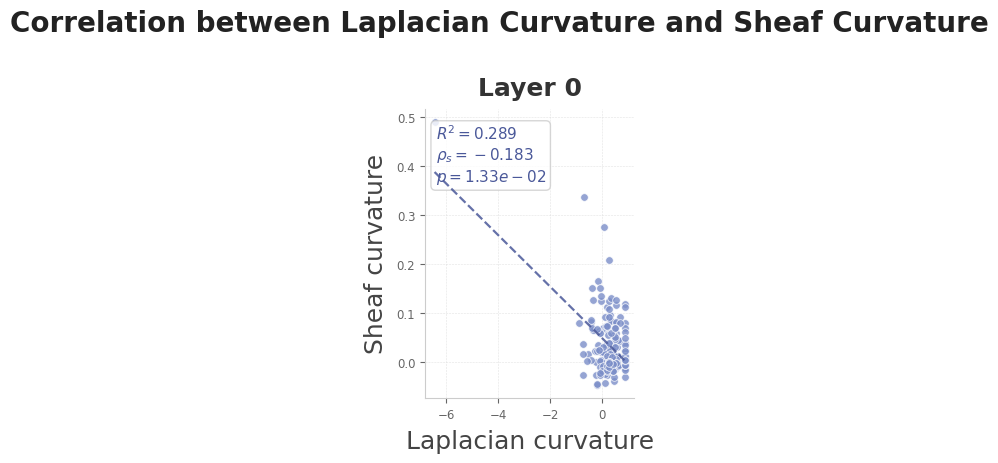

In [23]:
# plot the scatter plots between f0 and f0_top for all layers
import numpy as np
from scipy import stats

fig, axes = plt.subplots(nrows=1, ncols=layers, figsize=(3 * layers, 4.5),
                         sharey=True)

# Softer blue-purple palette
scatter_color = "#7B8EC8"   # muted indigo-blue
line_color    = "#4A5899"   # slightly deeper for the regression line

degrees = f0_top

for layer in range(layers):
    #ax = axes[layer]
    ax = axes
    y  = f0_list[layer]

    # Scatter
    ax.scatter(degrees, y,
               color=scatter_color,
               alpha=0.8,
               s=30,
               edgecolors="white",
               linewidths=0.6,
               zorder=3)

    # Linear regression
    slope, intercept, r_value, _, _ = stats.linregress(degrees, y)
    r2 = r_value**2
    x_range = np.linspace(min(degrees), max(degrees), 200)
    ax.plot(x_range, slope * x_range + intercept,
            color=line_color,
            linewidth=1.6,
            linestyle="--",
            alpha=0.85,
            zorder=4)

    # Spearman correlation
    spearman_r, spearman_p = stats.spearmanr(degrees, y)

    # Annotation with both metrics
    stats_text = f"$R^2 = {r2:.3f}$\n$\\rho_s = {spearman_r:.3f}$\n$p = {spearman_p:.2e}$"
    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes,
            fontsize=11,
            color=line_color,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", alpha=0.8))

    # Subtle grid
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)

    # Spine cleanup — keep only bottom and left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    # Labels
    ax.set_xlabel("Laplacian curvature", fontsize=18, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("Sheaf curvature", fontsize=18,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer}", fontsize=18, fontweight="semibold",
                 color="#333333", pad=10)

    ax.tick_params(colors="#666666", labelsize=8.5)

fig.suptitle("Correlation between Laplacian Curvature and Sheaf Curvature",
             fontsize=20, fontweight="semibold", color="#222222", y=1.02)

plt.tight_layout()
plt.show()
#fig.savefig(f"../results/images/0-f0_degree_correlation_{dataset}_{layers}-layers_{epochs}epochs.pdf")

In [24]:
# calculate correlation between L0 entries and L0_top entries, for each layer
# and also between L1 entries and L1_top entries, for each layer
correlations_0 = []
correlations_1 = []
for layer in range(layers):
    L0 = L0_LIST[layer]
    L0_top = L0_top
    L1 = L1_LIST[layer]
    L1_top = L1_top
    # calculate spearman correlation and calculate p value
    corr_0, p_value_0 = scipy.stats.spearmanr(L0.flatten(), L0_top.flatten())
    corr_1, p_value_1 = scipy.stats.spearmanr(L1.flatten(), L1_top.flatten())
    correlations_0.append(corr_0)
    correlations_1.append(corr_1)
    print(f"Layer {layer}: Correlation 0 = {corr_0:.4f}, P-Value = {p_value_0:.4f}")
    print(f"Layer {layer}: Correlation 1 = {corr_1:.4f}, P-Value = {p_value_1:.4f}")

NameError: name 'scipy' is not defined

In [25]:
# compute correlation between entries of the unnormalized Laplacians L0 and L0_top, and between L1 and L1_top
correlations_0_un = []
correlations_1_un = []
for layer in range(layers):
    L0_un = L0_LIST_un[layer]
    L1_un = L1_LIST_un[layer]
    # calculate spearman correlation and calculate p value
    corr_0_un, p_value_0_un = scipy.stats.spearmanr(L0_un.flatten(), L0_top_un.flatten())
    corr_1_un, p_value_1_un = scipy.stats.spearmanr(L1_un.flatten(), L1_top_un.flatten())
    correlations_0_un.append(corr_0_un)
    correlations_1_un.append(corr_1_un)
    print(f"Layer {layer}: Correlation 0 (Unnormalized) = {corr_0_un:.4f}, P-Value = {p_value_0_un:.4f}")
    print(f"Layer {layer}: Correlation 1 (Unnormalized) = {corr_1_un:.4f}, P-Value = {p_value_1_un:.4f}")

NameError: name 'scipy' is not defined

In [ ]:
# calculate the correlation between f0 and f0_top for all layers, from the unnormalized Laplacians
correlations_f0_un = []
B0_top_un, F0_top_un = fbc(L0_top_un)
f0_top_un = np.diag(F0_top_un)
for layer in range(layers):
    B0_un, F0_un = fbc(L0_LIST_un[layer])
    f0 = np.diag(F0_un)
    f0_top = f0_top_un
    corr_f0_un, p_value_f0_un = scipy.stats.spearmanr(f0.flatten(), f0_top.flatten())
    correlations_f0_un.append(corr_f0_un)
    print(f"Layer {layer}: Correlation f0 (Unnormalized) = {corr_f0_un:.4f}, P-Value = {p_value_f0_un:.4f}")

Layer 0: Correlation f0 (Unnormalized) = nan, P-Value = nan
Layer 1: Correlation f0 (Unnormalized) = nan, P-Value = nan
Layer 2: Correlation f0 (Unnormalized) = nan, P-Value = nan


C:\Users\Utente\AppData\Local\Temp\ipykernel_6768\143403435.py:9: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr_f0_un, p_value_f0_un = scipy.stats.spearmanr(f0.flatten(), f0_top.flatten())


In [119]:
# calculate the correlation between f1 and f1_top for all layers, from the unnormalized Laplacians
correlations_f1_un = []
B1_top_un, F1_top_un = fbc(L1_top_un)
f1_top_un = np.diag(F1_top_un)
for layer in range(layers):
    B1_un, F1_un = fbc(L1_LIST_un[layer])
    f1 = np.diag(F1_un)
    f1_top = f1_top_un
    corr_f1_un, p_value_f1_un = scipy.stats.spearmanr(f1.flatten(), f1_top.flatten())
    correlations_f1_un.append(corr_f1_un)
    print(f"Layer {layer}: Correlation f1 (Unnormalized) = {corr_f1_un:.4f}, P-Value = {p_value_f1_un:.4f}")

Layer 0: Correlation f1 (Unnormalized) = 0.8034, P-Value = 0.0000
Layer 1: Correlation f1 (Unnormalized) = 0.8049, P-Value = 0.0000
Layer 2: Correlation f1 (Unnormalized) = 0.8375, P-Value = 0.0000


In [ ]:
# plot the u

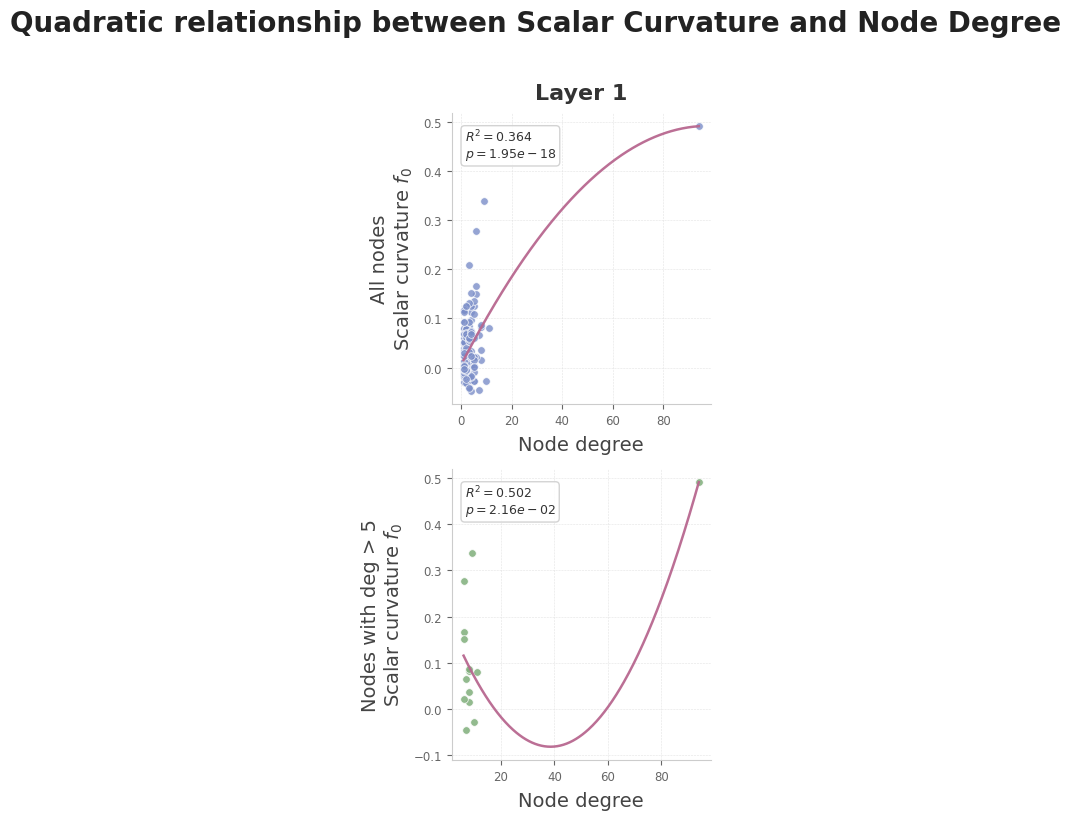

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

def fit_quadratic_model(x, y):
    """
    Fit y ~ 1 + x + x^2 via OLS.
    Returns fitted model and a callable predictor.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    X = np.column_stack([x, x**2])
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()

    def predict_fn(x_new):
        x_new = np.asarray(x_new, dtype=float)
        X_new = np.column_stack([x_new, x_new**2])
        X_new = sm.add_constant(X_new)
        return model.predict(X_new)

    return model, predict_fn


def add_quad_annotation(ax, model, label=None):
    r2 = model.rsquared
    pval = model.f_pvalue

    p_text = "NA" if (pval is None or np.isnan(pval)) else f"{pval:.2e}"

    txt = (
        f"$R^2 = {r2:.3f}$\n"
        f"$p = {p_text}$"
    )
    if label is not None:
        txt = f"{label}\n" + txt

    ax.text(
        0.05, 0.95, txt,
        transform=ax.transAxes,
        fontsize=9,
        color="#333333",
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="#cccccc",
            alpha=0.85
        )
    )


fig, axes = plt.subplots(
    nrows=2,
    ncols=layers,
    figsize=(3.8 * layers, 8.0),
    sharey='row'
)

if layers == 1:
    axes = np.array(axes).reshape(2, 1)

scatter_color_all = "#7B8EC8"
scatter_color_sub = "#7FAE7A"
poly_color = "#B8678F"

degrees = np.array([G.degree(n) for n in G.nodes()], dtype=float)

for layer in range(layers):
    y = np.asarray(f0_list[layer], dtype=float)

    # Common finite mask
    mask_all = np.isfinite(degrees) & np.isfinite(y)

    # =========================
    # Top row: all nodes
    # =========================
    ax = axes[0, layer]
    x_all = degrees[mask_all]
    y_all = y[mask_all]

    ax.scatter(
        x_all, y_all,
        color=scatter_color_all,
        alpha=0.8,
        s=30,
        edgecolors="white",
        linewidths=0.6,
        zorder=3
    )

    if len(x_all) >= 4 and len(np.unique(x_all)) >= 3:
        model_all, pred_all = fit_quadratic_model(x_all, y_all)
        x_range = np.linspace(np.min(x_all), np.max(x_all), 300)

        ax.plot(
            x_range,
            pred_all(x_range),
            color=poly_color,
            linewidth=1.8,
            linestyle="-",
            alpha=0.95,
            zorder=5
        )

        add_quad_annotation(ax, model_all)
    else:
        ax.text(
            0.05, 0.95,
            "Too few distinct points\nfor quadratic fit",
            transform=ax.transAxes,
            fontsize=9,
            color="#333333",
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#cccccc",
                alpha=0.85
            )
        )

    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(colors="#666666", labelsize=8.5)

    ax.set_xlabel("Node degree", fontsize=14, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("All nodes\nScalar curvature $f_0$", fontsize=14,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer+1}", fontsize=16, fontweight="semibold",
                 color="#333333", pad=10)

    # =========================
    # Bottom row: degree > 5
    # =========================
    
    degrees_threshold = 5
    ax2 = axes[1, layer]
    mask_sub = mask_all & (degrees > degrees_threshold)
    x_sub = degrees[mask_sub]
    y_sub = y[mask_sub]

    ax2.scatter(
        x_sub, y_sub,
        color=scatter_color_sub,
        alpha=0.85,
        s=30,
        edgecolors="white",
        linewidths=0.6,
        zorder=3
    )

    if len(x_sub) >= 4 and len(np.unique(x_sub)) >= 3:
        model_sub, pred_sub = fit_quadratic_model(x_sub, y_sub)
        x_range_sub = np.linspace(np.min(x_sub), np.max(x_sub), 300)

        ax2.plot(
            x_range_sub,
            pred_sub(x_range_sub),
            color=poly_color,
            linewidth=1.8,
            linestyle="-",
            alpha=0.95,
            zorder=5
        )

        add_quad_annotation(ax2, model_sub)
    else:
        ax2.text(
            0.05, 0.95,
            "Too few distinct points\nfor quadratic fit",
            transform=ax2.transAxes,
            fontsize=9,
            color="#333333",
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#cccccc",
                alpha=0.85
            )
        )

    ax2.set_axisbelow(True)
    ax2.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_color("#cccccc")
    ax2.spines["bottom"].set_color("#cccccc")
    ax2.tick_params(colors="#666666", labelsize=8.5)

    ax2.set_xlabel("Node degree", fontsize=14, color="#444444", labelpad=6)
    if layer == 0:
        ax2.set_ylabel(f"Nodes with deg > {degrees_threshold}\nScalar curvature $f_0$", fontsize=14,
                       color="#444444", labelpad=6)

fig.suptitle(
    "Quadratic relationship between Scalar Curvature and Node Degree",
    fontsize=20,
    fontweight="semibold",
    color="#222222",
    y=1.02
)

plt.tight_layout()
plt.show()

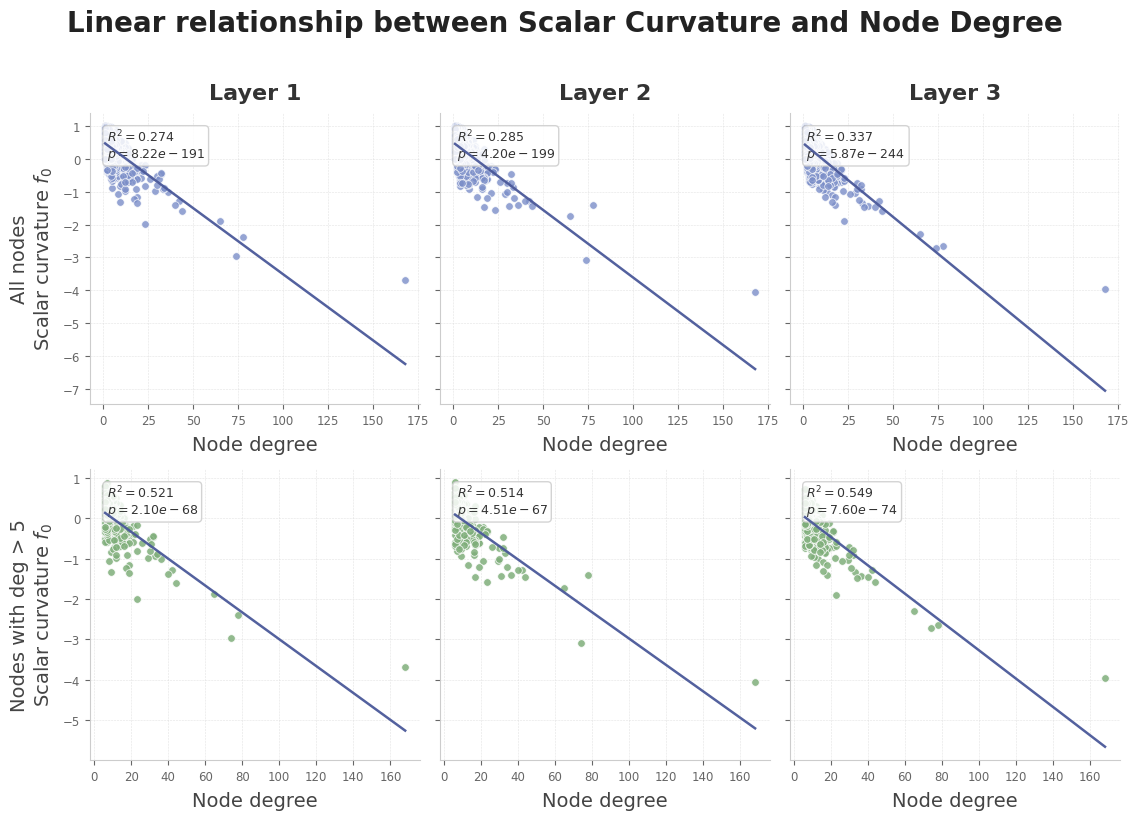

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

def fit_linear_model(x, y):
    """
    Fit y ~ 1 + x via OLS.
    Returns fitted model and a callable predictor.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    X = sm.add_constant(x)   # [1, x]
    model = sm.OLS(y, X).fit()

    def predict_fn(x_new):
        x_new = np.asarray(x_new, dtype=float)
        X_new = sm.add_constant(x_new)
        return model.predict(X_new)

    return model, predict_fn


def add_lin_annotation(ax, model, label=None):
    r2 = model.rsquared
    pval = model.f_pvalue

    p_text = "NA" if (pval is None or np.isnan(pval)) else f"{pval:.2e}"

    txt = (
        f"$R^2 = {r2:.3f}$\n"
        f"$p = {p_text}$"
    )
    if label is not None:
        txt = f"{label}\n" + txt

    ax.text(
        0.05, 0.95, txt,
        transform=ax.transAxes,
        fontsize=9,
        color="#333333",
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="#cccccc",
            alpha=0.85
        )
    )


fig, axes = plt.subplots(
    nrows=2,
    ncols=layers,
    figsize=(3.8 * layers, 8.0),
    sharey='row'
)

if layers == 1:
    axes = np.array(axes).reshape(2, 1)

scatter_color_all = "#7B8EC8"
scatter_color_sub = "#7FAE7A"
line_color = "#4A5899"

degrees = np.array([G.degree(n) for n in G.nodes()], dtype=float)

for layer in range(layers):
    y = np.asarray(f0_list[layer], dtype=float)

    mask_all = np.isfinite(degrees) & np.isfinite(y)

    # =========================
    # Top row: all nodes
    # =========================
    ax = axes[0, layer]
    x_all = degrees[mask_all]
    y_all = y[mask_all]

    ax.scatter(
        x_all, y_all,
        color=scatter_color_all,
        alpha=0.8,
        s=30,
        edgecolors="white",
        linewidths=0.6,
        zorder=3
    )

    if len(x_all) >= 2 and len(np.unique(x_all)) >= 2:
        model_all, pred_all = fit_linear_model(x_all, y_all)
        x_range = np.linspace(np.min(x_all), np.max(x_all), 300)

        ax.plot(
            x_range,
            pred_all(x_range),
            color=line_color,
            linewidth=1.8,
            linestyle="-",
            alpha=0.95,
            zorder=5
        )

        add_lin_annotation(ax, model_all)
    else:
        ax.text(
            0.05, 0.95,
            "Too few distinct points\nfor linear fit",
            transform=ax.transAxes,
            fontsize=9,
            color="#333333",
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#cccccc",
                alpha=0.85
            )
        )

    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(colors="#666666", labelsize=8.5)

    ax.set_xlabel("Node degree", fontsize=14, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("All nodes\nScalar curvature $f_0$", fontsize=14,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer+1}", fontsize=16, fontweight="semibold",
                 color="#333333", pad=10)

    # =========================
    # Bottom row: degree > 5
    # =========================
    ax2 = axes[1, layer]
    mask_sub = mask_all & (degrees > 5)
    x_sub = degrees[mask_sub]
    y_sub = y[mask_sub]

    ax2.scatter(
        x_sub, y_sub,
        color=scatter_color_sub,
        alpha=0.85,
        s=30,
        edgecolors="white",
        linewidths=0.6,
        zorder=3
    )

    if len(x_sub) >= 2 and len(np.unique(x_sub)) >= 2:
        model_sub, pred_sub = fit_linear_model(x_sub, y_sub)
        x_range_sub = np.linspace(np.min(x_sub), np.max(x_sub), 300)

        ax2.plot(
            x_range_sub,
            pred_sub(x_range_sub),
            color=line_color,
            linewidth=1.8,
            linestyle="-",
            alpha=0.95,
            zorder=5
        )

        add_lin_annotation(ax2, model_sub)
    else:
        ax2.text(
            0.05, 0.95,
            "Too few distinct points\nfor linear fit",
            transform=ax2.transAxes,
            fontsize=9,
            color="#333333",
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#cccccc",
                alpha=0.85
            )
        )

    ax2.set_axisbelow(True)
    ax2.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_color("#cccccc")
    ax2.spines["bottom"].set_color("#cccccc")
    ax2.tick_params(colors="#666666", labelsize=8.5)

    ax2.set_xlabel("Node degree", fontsize=14, color="#444444", labelpad=6)
    if layer == 0:
        ax2.set_ylabel("Nodes with deg > 5\nScalar curvature $f_0$", fontsize=14,
                       color="#444444", labelpad=6)

fig.suptitle(
    "Linear relationship between Scalar Curvature and Node Degree",
    fontsize=20,
    fontweight="semibold",
    color="#222222",
    y=1.02
)

plt.tight_layout()
plt.show()

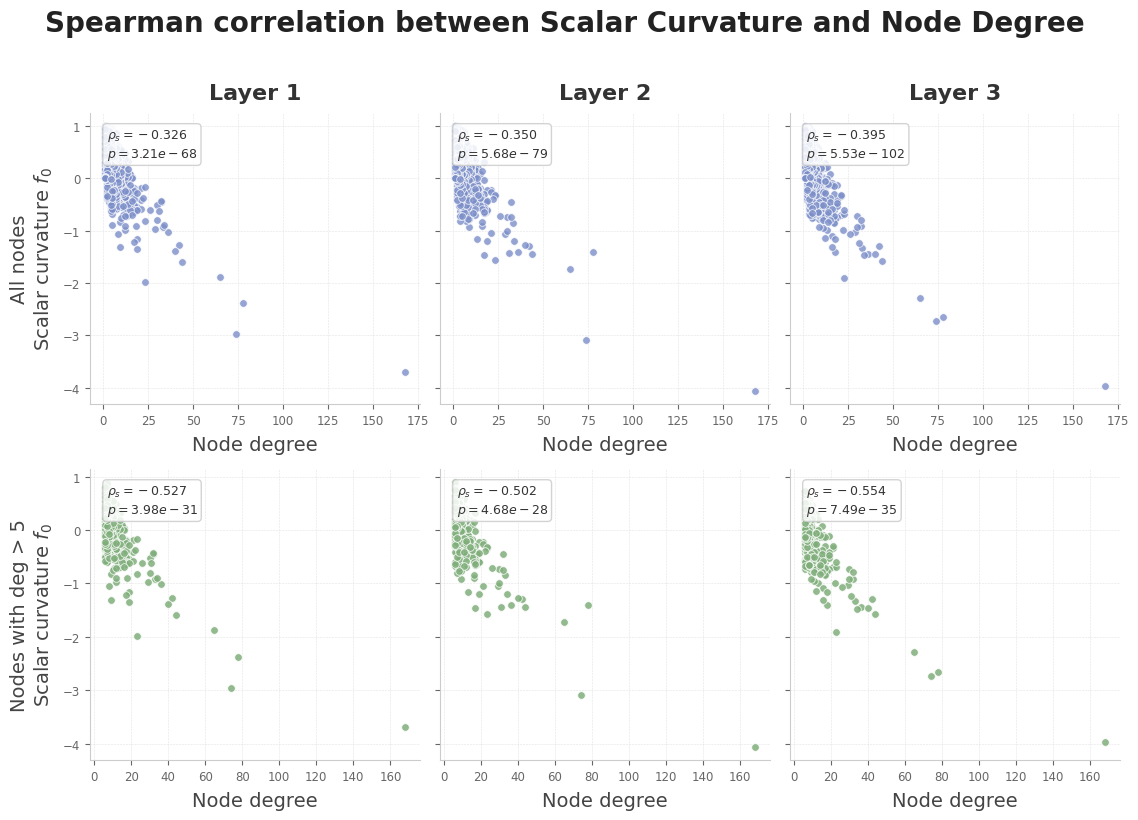

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

fig, axes = plt.subplots(
    nrows=2,
    ncols=layers,
    figsize=(3.8 * layers, 8.0),
    sharey='row'
)

if layers == 1:
    axes = np.array(axes).reshape(2, 1)

scatter_color_all = "#7B8EC8"
scatter_color_sub = "#7FAE7A"

degrees = np.array([G.degree(n) for n in G.nodes()], dtype=float)

def add_spearman_annotation(ax, rho, pval):
    p_text = "NA" if (pval is None or np.isnan(pval)) else f"{pval:.2e}"
    txt = (
        f"$\\rho_s = {rho:.3f}$\n"
        f"$p = {p_text}$"
    )
    ax.text(
        0.05, 0.95, txt,
        transform=ax.transAxes,
        fontsize=9,
        color="#333333",
        verticalalignment="top",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="#cccccc",
            alpha=0.85
        )
    )

for layer in range(layers):
    y = np.asarray(f0_list[layer], dtype=float)
    mask_all = np.isfinite(degrees) & np.isfinite(y)

    # =========================
    # Top row: all nodes
    # =========================
    ax = axes[0, layer]
    x_all = degrees[mask_all]
    y_all = y[mask_all]

    ax.scatter(
        x_all, y_all,
        color=scatter_color_all,
        alpha=0.8,
        s=30,
        edgecolors="white",
        linewidths=0.6,
        zorder=3
    )

    if len(x_all) >= 2 and len(np.unique(x_all)) >= 2 and len(np.unique(y_all)) >= 2:
        rho_all, p_all = spearmanr(x_all, y_all)
        add_spearman_annotation(ax, rho_all, p_all)
    else:
        ax.text(
            0.05, 0.95,
            "Too few distinct points\nfor Spearman correlation",
            transform=ax.transAxes,
            fontsize=9,
            color="#333333",
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#cccccc",
                alpha=0.85
            )
        )

    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(colors="#666666", labelsize=8.5)

    ax.set_xlabel("Node degree", fontsize=14, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("All nodes\nScalar curvature $f_0$", fontsize=14,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer+1}", fontsize=16, fontweight="semibold",
                 color="#333333", pad=10)

    # =========================
    # Bottom row: degree > 5
    # =========================
    ax2 = axes[1, layer]
    mask_sub = mask_all & (degrees > 5)
    x_sub = degrees[mask_sub]
    y_sub = y[mask_sub]

    ax2.scatter(
        x_sub, y_sub,
        color=scatter_color_sub,
        alpha=0.85,
        s=30,
        edgecolors="white",
        linewidths=0.6,
        zorder=3
    )

    if len(x_sub) >= 2 and len(np.unique(x_sub)) >= 2 and len(np.unique(y_sub)) >= 2:
        rho_sub, p_sub = spearmanr(x_sub, y_sub)
        add_spearman_annotation(ax2, rho_sub, p_sub)
    else:
        ax2.text(
            0.05, 0.95,
            "Too few distinct points\nfor Spearman correlation",
            transform=ax2.transAxes,
            fontsize=9,
            color="#333333",
            verticalalignment="top",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor="#cccccc",
                alpha=0.85
            )
        )

    ax2.set_axisbelow(True)
    ax2.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_color("#cccccc")
    ax2.spines["bottom"].set_color("#cccccc")
    ax2.tick_params(colors="#666666", labelsize=8.5)

    ax2.set_xlabel("Node degree", fontsize=14, color="#444444", labelpad=6)
    if layer == 0:
        ax2.set_ylabel("Nodes with deg > 5\nScalar curvature $f_0$", fontsize=14,
                       color="#444444", labelpad=6)

fig.suptitle(
    "Spearman correlation between Scalar Curvature and Node Degree",
    fontsize=20,
    fontweight="semibold",
    color="#222222",
    y=1.02
)

plt.tight_layout()
plt.show()

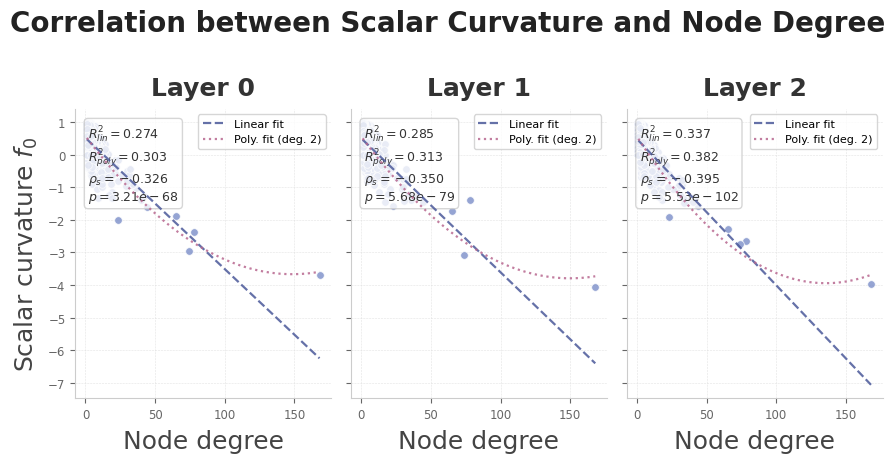

In [ ]:
import numpy as np
from scipy import stats

fig, axes = plt.subplots(nrows=1, ncols=layers, figsize=(3 * layers, 4.5),
                         sharey=True)

# Softer blue-purple palette
scatter_color = "#7B8EC8"   # muted indigo-blue
line_color    = "#4A5899"   # slightly deeper for the regression line
poly_color    = "#B8678F"   # muted rose for the polynomial fit

degrees = np.array([len(G.edges(n)) for n in G.nodes()])

for layer in range(layers):
    ax = axes[layer]
    y  = np.array(f0_list[layer])

    # Scatter
    ax.scatter(degrees, y,
               color=scatter_color,
               alpha=0.8,
               s=30,
               edgecolors="white",
               linewidths=0.6,
               zorder=3)

    # Linear regression
    slope, intercept, r_value, _, _ = stats.linregress(degrees, y)
    r2 = r_value**2
    x_range = np.linspace(min(degrees), max(degrees), 200)
    ax.plot(x_range, slope * x_range + intercept,
            color=line_color,
            linewidth=1.6,
            linestyle="--",
            alpha=0.85,
            zorder=4,
            label="Linear fit")

    # Degree-2 polynomial fit
    poly_coeffs = np.polyfit(degrees, y, 2)
    poly_fn     = np.poly1d(poly_coeffs)
    ax.plot(x_range, poly_fn(x_range),
            color=poly_color,
            linewidth=1.6,
            linestyle=":",
            alpha=0.85,
            zorder=4,
            label="Poly. fit (deg. 2)")

    # R² for polynomial fit
    y_pred_poly = poly_fn(degrees)
    ss_res = np.sum((y - y_pred_poly) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2_poly = 1 - ss_res / ss_tot

    # Spearman correlation
    spearman_r, spearman_p = stats.spearmanr(degrees, y)

    # Annotation with all metrics
    stats_text = (f"$R^2_{{lin}} = {r2:.3f}$\n"
                  f"$R^2_{{poly}} = {r2_poly:.3f}$\n"
                  f"$\\rho_s = {spearman_r:.3f}$\n"
                  f"$p = {spearman_p:.2e}$")
    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes,
            fontsize=9,
            color="#333333",
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", alpha=0.8))

    # Legend
    ax.legend(fontsize=8, framealpha=0.8, edgecolor="#cccccc",
              loc="best")

    # Subtle grid
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)

    # Spine cleanup — keep only bottom and left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    # Labels
    ax.set_xlabel("Node degree", fontsize=18, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("Scalar curvature $f_0$", fontsize=18,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer}", fontsize=18, fontweight="semibold",
                 color="#333333", pad=10)

    ax.tick_params(colors="#666666", labelsize=8.5)

fig.suptitle("Correlation between Scalar Curvature and Node Degree",
             fontsize=20, fontweight="semibold", color="#222222", y=1.02)

plt.tight_layout()
plt.show()
#fig.savefig(f"../results/images/0-f0_degree_correlation_{dataset}_{layers}-layers_{epochs}epochs.pdf")

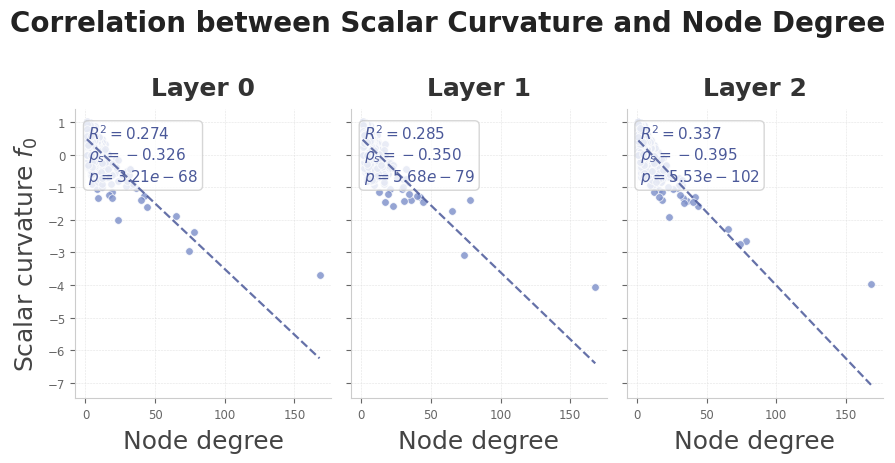

In [ ]:
import numpy as np
from scipy import stats

fig, axes = plt.subplots(nrows=1, ncols=layers, figsize=(3 * layers, 4.5),
                         sharey=True)

# Softer blue-purple palette
scatter_color = "#7B8EC8"   # muted indigo-blue
line_color    = "#4A5899"   # slightly deeper for the regression line

degrees = [len(G.edges(n)) for n in G.nodes()]

for layer in range(layers):
    ax = axes[layer]
    y  = f0_list[layer]

    # Scatter
    ax.scatter(degrees, y,
               color=scatter_color,
               alpha=0.8,
               s=30,
               edgecolors="white",
               linewidths=0.6,
               zorder=3)

    # Linear regression
    slope, intercept, r_value, _, _ = stats.linregress(degrees, y)
    r2 = r_value**2
    x_range = np.linspace(min(degrees), max(degrees), 200)
    ax.plot(x_range, slope * x_range + intercept,
            color=line_color,
            linewidth=1.6,
            linestyle="--",
            alpha=0.85,
            zorder=4)

    # Spearman correlation
    spearman_r, spearman_p = stats.spearmanr(degrees, y)

    # Annotation with both metrics
    stats_text = f"$R^2 = {r2:.3f}$\n$\\rho_s = {spearman_r:.3f}$\n$p = {spearman_p:.2e}$"
    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes,
            fontsize=11,
            color=line_color,
            verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor="#cccccc", alpha=0.8))

    # Subtle grid
    ax.set_axisbelow(True)
    ax.grid(True, linestyle="--", linewidth=0.4, color="gainsboro", alpha=0.8)

    # Spine cleanup — keep only bottom and left
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    # Labels
    ax.set_xlabel("Node degree", fontsize=18, color="#444444", labelpad=6)
    if layer == 0:
        ax.set_ylabel("Scalar curvature $f_0$", fontsize=18,
                      color="#444444", labelpad=6)
    ax.set_title(f"Layer {layer}", fontsize=18, fontweight="semibold",
                 color="#333333", pad=10)

    ax.tick_params(colors="#666666", labelsize=8.5)

fig.suptitle("Correlation between Scalar Curvature and Node Degree",
             fontsize=20, fontweight="semibold", color="#222222", y=1.02)

plt.tight_layout()
plt.show()
#fig.savefig(f"../results/images/0-f0_degree_correlation_{dataset}_{layers}-layers_{epochs}epochs.pdf")

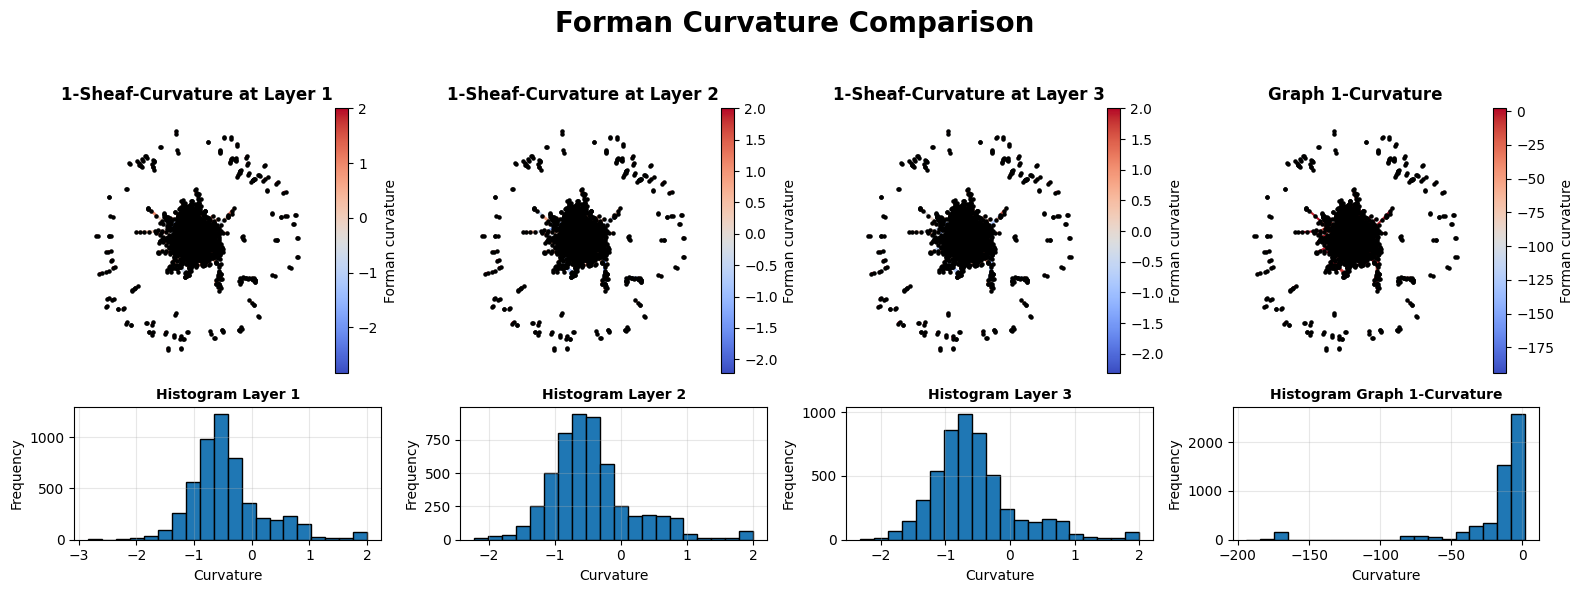

In [ ]:
pos = nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(4 * (layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

for layer in range(layers):
    curvatures = np.asarray(f1_list[layer])

    # ----- Top row: graph -----
    ax_graph = ax[0, layer]
    nx.draw_networkx_nodes(
        G, ax=ax_graph, pos=pos,
        node_color='k', node_size=5
    )

    norm = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())
    nx.draw_networkx_edges(
        G, ax=ax_graph, pos=pos,
        edge_color=cmap(norm(curvatures)),
        width=2
    )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax_graph, label='Forman curvature')

    ax_graph.set_title(
        f"1-Sheaf-Curvature at Layer {layer+1}",
        fontweight="bold", fontsize=12
    )
    ax_graph.axis("off")

    # ----- Bottom row: histogram -----
    ax_hist = ax[1, layer]
    ax_hist.hist(curvatures, bins=20, edgecolor="black")
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10, fontweight="bold"
    )
    ax_hist.set_xlabel("Curvature")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)


# ----- Last column: top graph curvature -----
curvatures_top = np.asarray(f1_top)

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G, ax=ax_graph, pos=pos,
    node_color='k', node_size=5
)

norm_top = plt.Normalize(vmin=curvatures_top.min(), vmax=curvatures_top.max())
nx.draw_networkx_edges(
    G, ax=ax_graph, pos=pos,
    edge_color=cmap(norm_top(curvatures_top)),
    width=1.5
)

sm_top = plt.cm.ScalarMappable(cmap=cmap, norm=norm_top)
sm_top.set_array([])
plt.colorbar(sm_top, ax=ax_graph, label='Forman curvature')

ax_graph.set_title(
    "Graph 1-Curvature",
    fontweight="bold", fontsize=12
)
ax_graph.axis("off")

# ----- Bottom row: histogram for top curvature -----
ax_hist = ax[1, layers]
ax_hist.hist(curvatures_top, bins=20, edgecolor="black")
ax_hist.set_title(
    "Histogram Graph 1-Curvature",
    fontsize=10, fontweight="bold"
)
ax_hist.set_xlabel("Curvature")
ax_hist.set_ylabel("Frequency")
ax_hist.grid(alpha=0.3)

fig.suptitle("Forman Curvature Comparison", fontsize=20, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
#os.makedirs("../results/images", exist_ok=True)
#fig.savefig(f"../results/images/1-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)

In [ ]:
with open(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", "r") as f:
    # for line in f:
    #     print(line.strip())
    df_node_feature = pd.read_csv(f"../datasets/{dataset}/raw/out1_node_feature_label.txt", sep="\t")

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/cora/raw/out1_node_feature_label.txt'

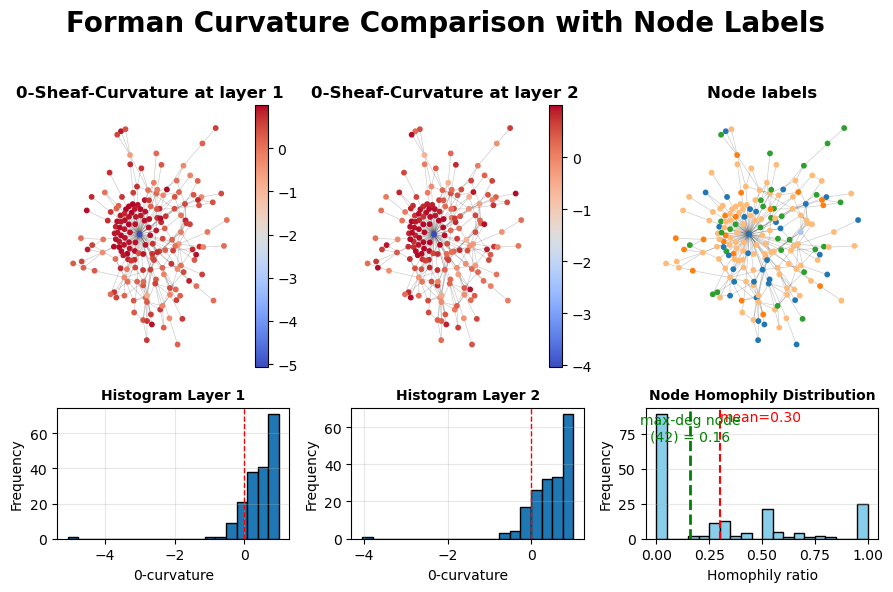

In [ ]:
from tkinter import font


lab = df_node_feature["label"].values
# display(lab)

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)
cmap = plt.cm.coolwarm

fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(3*(layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

# ---------- Sheaf curvature layers ----------
for layer in range(layers):
    curvatures = np.asarray(f0_list[layer])

    # Top row: graph
    ax_graph = ax[0, layer]
    norm0 = plt.Normalize(vmin=curvatures.min(), vmax=curvatures.max())

    nx.draw_networkx_nodes(
        G,
        ax=ax_graph,
        node_color=cmap(norm0(curvatures)),
        pos=pos_use,
        node_size=10
    )
    nx.draw_networkx_edges(
        G,
        ax=ax_graph,
        pos=pos_use,
        width=0.5,
        alpha=0.2
    )

    sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
    sm0.set_array([])
    plt.colorbar(sm0, ax=ax_graph)

    ax_graph.set_title(
        f"0-Sheaf-Curvature at layer {layer+1}",
        fontweight="bold",
        fontsize=12
    )
    ax_graph.axis("off")

    # Bottom row: histogram
    ax_hist = ax[1, layer]
    ax_hist.hist(curvatures, bins=20, edgecolor="black")
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1)
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10,
        fontweight="bold"
    )
    ax_hist.set_xlabel("0-curvature")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)


# ---------- Last column: node labels ----------
labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n])] % 20) for n in sorted(G.nodes())]

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G,
    ax=ax_graph,
    node_color=node_colors,
    node_size=10,
    pos=pos_use
)
nx.draw_networkx_edges(
    G,
    ax=ax_graph,
    pos=pos_use,
    alpha=0.2,
    width=0.5
)
ax_graph.set_title("Node labels", fontweight="bold", fontsize=12)
ax_graph.axis("off")

# ----- Bottom-right: homophily ratio histogram -----
homophily_ratios = {}

for node in G.nodes():
    neigh_edges = [_ for _ in list(G.edges()) if node in _]
    neigh_nodes = [int(j) if i == node else int(i) for (i, j) in neigh_edges]

    if len(neigh_nodes) == 0:
        homophily_ratios[node] = 0.0
        continue

    ratio = sum(1 for n in neigh_nodes if lab[n] == lab[node]) / len(neigh_nodes)
    homophily_ratios[node] = ratio

ax_hom = ax[1, layers]

ax_hom.hist(
    list(homophily_ratios.values()),
    bins=20,
    color='skyblue',
    edgecolor='black'
)

ax_hom.set_title(
    "Node Homophily Distribution",
    fontsize=10,
    fontweight="bold"
)
ax_hom.set_xlabel("Homophily ratio")
ax_hom.set_ylabel("Frequency")
ax_hom.grid(axis='y', alpha=0.3)

# Optional: mean line (very useful)
mean_h = np.mean(list(homophily_ratios.values()))
ax_hom.axvline(mean_h, color="red", linestyle="--", linewidth=1.5)
ax_hom.text(mean_h, ax_hom.get_ylim()[1]*0.9, f"mean={mean_h:.2f}", color="red", fontsize=10)

degrees = dict(G.degree())
max_deg_node = max(degrees, key=degrees.get)
max_deg_hom = homophily_ratios[max_deg_node]

ax_hom.axvline(max_deg_hom, color="green", linestyle="--", linewidth=2)

ax_hom.text(
    max_deg_hom,
    ax_hom.get_ylim()[1]*0.75,
    f"max-deg node\n({max_deg_node}) = {max_deg_hom:.2f}",
    color="green",
    ha="center"
)

fig.suptitle("Forman Curvature Comparison with Node Labels", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf")
#os.makedirs("../results/images", exist_ok=True)
#fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)

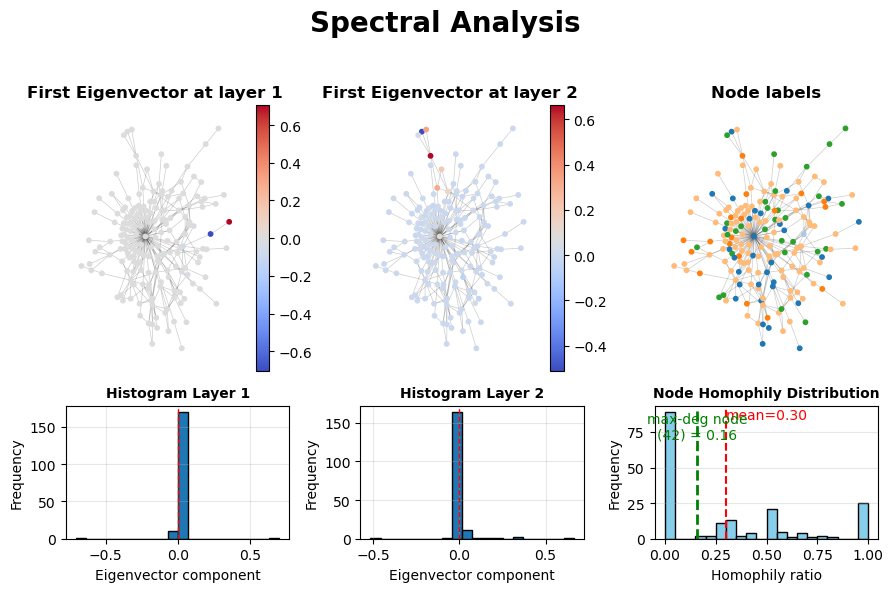

In [ ]:
fig, ax = plt.subplots(
    2, layers + 1,
    figsize=(3 * (layers + 1), 6),
    gridspec_kw={"height_ratios": [3, 1.5]}
)

# ---------- Sheaf curvature layers ----------
for layer in range(layers):
    eig00 = np.asarray(ev0_list[layer][:,0])

    # Top row: graph
    ax_graph = ax[0, layer]
    norm0 = plt.Normalize(vmin=eig00.min(), vmax=eig00.max())

    nx.draw_networkx_nodes(
        G,
        ax=ax_graph,
        node_color=cmap(norm0(eig00)),
        pos=pos_use,
        node_size=10
    )
    nx.draw_networkx_edges(
        G,
        ax=ax_graph,
        pos=pos_use,
        width=0.5,
        alpha=0.2
    )

    sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
    sm0.set_array([])
    plt.colorbar(sm0, ax=ax_graph)

    ax_graph.set_title(
        f"First Eigenvector at layer {layer+1}",
        fontweight="bold",
        fontsize=12
    )
    ax_graph.axis("off")

    # Bottom row: histogram
    ax_hist = ax[1, layer]
    ax_hist.hist(eig00, bins=20, edgecolor="black")
    ax_hist.axvline(0, color="red", linestyle="--", linewidth=1)
    ax_hist.set_title(
        f"Histogram Layer {layer+1}",
        fontsize=10,
        fontweight="bold"
    )
    ax_hist.set_xlabel("Eigenvector component")
    ax_hist.set_ylabel("Frequency")
    ax_hist.grid(alpha=0.3)

# ---------- Last column: node labels ----------
labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n])] % 20) for n in sorted(G.nodes())]

ax_graph = ax[0, layers]
nx.draw_networkx_nodes(
    G,
    ax=ax_graph,
    node_color=node_colors,
    node_size=10,
    pos=pos_use
)
nx.draw_networkx_edges(
    G,
    ax=ax_graph,
    pos=pos_use,
    alpha=0.2,
    width=0.5
)
ax_graph.set_title("Node labels", fontweight="bold", fontsize=12)
ax_graph.axis("off")

# ----- Bottom-right: homophily ratio histogram -----
homophily_ratios = {}

for node in G.nodes():
    neigh_edges = [_ for _ in list(G.edges()) if node in _]
    neigh_nodes = [int(j) if i == node else int(i) for (i, j) in neigh_edges]

    if len(neigh_nodes) == 0:
        homophily_ratios[node] = 0.0
        continue

    ratio = sum(1 for n in neigh_nodes if lab[n] == lab[node]) / len(neigh_nodes)
    homophily_ratios[node] = ratio

ax_hom = ax[1, layers]

ax_hom.hist(
    list(homophily_ratios.values()),
    bins=20,
    color='skyblue',
    edgecolor='black'
)

ax_hom.set_title(
    "Node Homophily Distribution",
    fontsize=10,
    fontweight="bold"
)
ax_hom.set_xlabel("Homophily ratio")
ax_hom.set_ylabel("Frequency")
ax_hom.grid(axis='y', alpha=0.3)

# Optional: mean line (very useful)
mean_h = np.mean(list(homophily_ratios.values()))
ax_hom.axvline(mean_h, color="red", linestyle="--", linewidth=1.5)
ax_hom.text(mean_h, ax_hom.get_ylim()[1]*0.9, f"mean={mean_h:.2f}", color="red", fontsize=10)

degrees = dict(G.degree())
max_deg_node = max(degrees, key=degrees.get)
max_deg_hom = homophily_ratios[max_deg_node]

ax_hom.axvline(max_deg_hom, color="green", linestyle="--", linewidth=2)

ax_hom.text(
    max_deg_hom,
    ax_hom.get_ylim()[1]*0.75,
    f"max-deg node\n({max_deg_node}) = {max_deg_hom:.2f}",
    color="green",
    ha="center"
)

fig.suptitle("Spectral Analysis", fontsize=20, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

#os.makedirs("../results/images", exist_ok=True)
#fig.savefig(f"../results/images/0-curvature_comparison_{dataset}_{layers}-layers_500epochs.pdf", dpi=300)